# Vintage plots

Two views of how the vintage cubes structure information:

1. **Revision history** — for a fixed observation (e.g. GDP 2008-Q4), plot the value as reported at each successive vintage release. Shows the revision process for a single number.
2. **Real-time-series overlay** ('vintage triangle') — pick a handful of vintage dates and overlay the full historical series as it stood on each date. Shows how the *picture of history* evolves with new releases and benchmark revisions.

Both panels also show why we needed the cube: for GDP, the level revisions are dominated by base-year rebasings, not by economic re-estimates.

In [1]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml
from fredapi import Fred

import vintage_store

ROOT = Path.cwd().parent

CUBES = {
    code: vintage_store.load_cube(ROOT / f'data/vintages/cubes/{code}.parquet')
    for code in ['GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS', 'CPIAUCSL', 'UMCSENT']
}
print('cubes loaded:', list(CUBES.keys()))

cfg = yaml.safe_load(open(ROOT / 'config.yaml'))
fred = Fred(api_key=cfg['api_key'])
nber = fred.get_series('USRECM').reindex(pd.date_range('1990-01-01', '2026-05-01', freq='MS'))

def recession_bands(s):
    s = s.fillna(0).astype(int); out, in_rec, start = [], False, None
    for d, v in s.items():
        if v == 1 and not in_rec: start, in_rec = d, True
        elif v == 0 and in_rec:   out.append((start, d)); in_rec = False
    if in_rec: out.append((start, s.index[-1]))
    return out

BANDS = recession_bands(nber)

cubes loaded: ['GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS', 'CPIAUCSL', 'UMCSENT']


## 1. Revision history for a single observation

For each `(series, obs_date)` pair below, we read the *row* of the cube and plot value vs vintage date. The step function shows when revisions happened; red marks the first release, green the latest.

Worth noticing:
- **GDP 2008-Q4 and 2020-Q2**: huge level jumps are mostly **base-year rebasings** (2000$ → 2005$ → 2009$ → 2012$ → 2017$). Not economic revisions per se — which is exactly why we built the vintage cube.
- **Payrolls March 2020**: ~900k revision downward over six years — annual benchmark adjustments.
- **Unemployment April 2020**: tiny revision (14.7 → 14.8). Household survey doesn't get much revised.
- **CPI June 2022**: <0.2% revision. CPI almost never moves after first release.
- **Michigan Sentiment Nov 2008**: flat line — Michigan revises *only the current month* (prelim → final), never historical values.

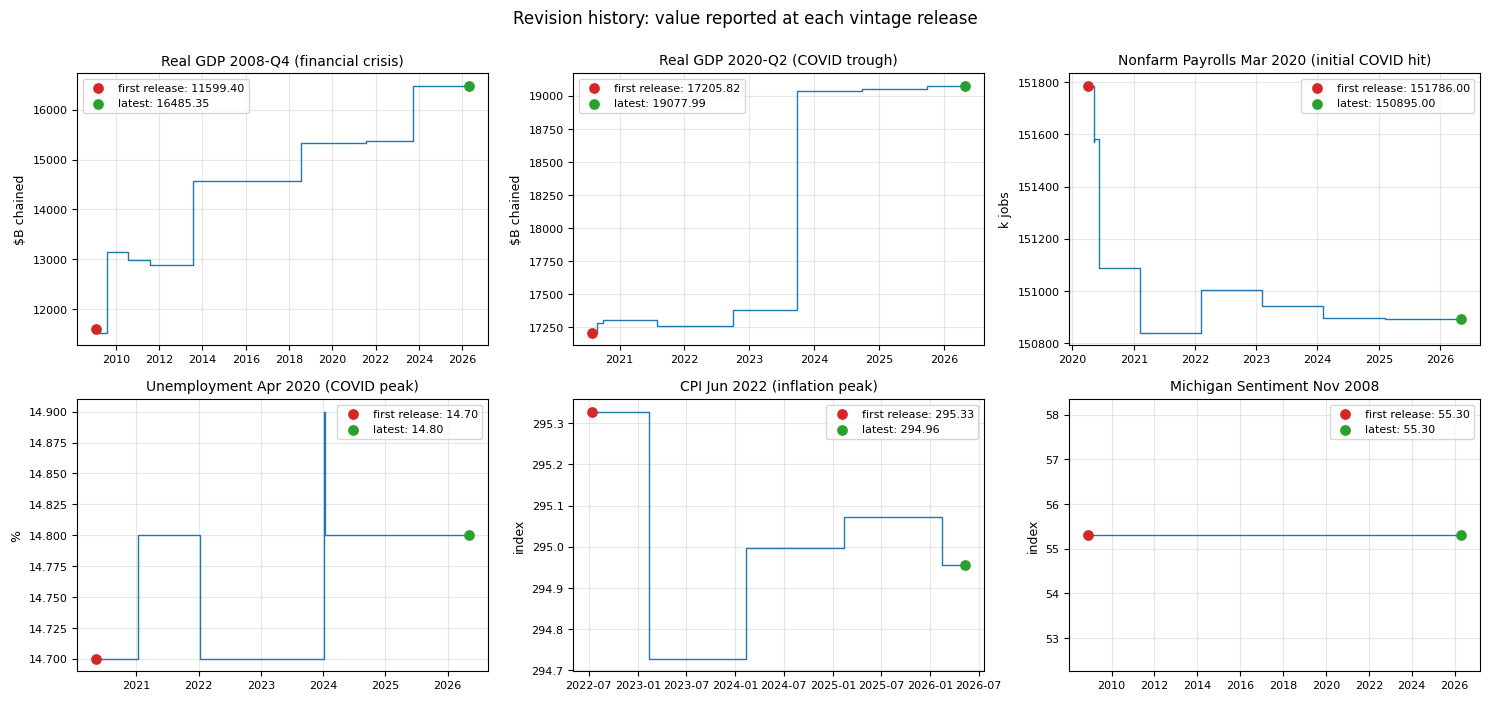

In [2]:
picks = [
    ('GDPC1',    '2008-10-01', 'Real GDP 2008-Q4 (financial crisis)',          '$B chained'),
    ('GDPC1',    '2020-04-01', 'Real GDP 2020-Q2 (COVID trough)',              '$B chained'),
    ('PAYEMS',   '2020-03-01', 'Nonfarm Payrolls Mar 2020 (initial COVID hit)','k jobs'),
    ('UNRATE',   '2020-04-01', 'Unemployment Apr 2020 (COVID peak)',           '%'),
    ('CPIAUCSL', '2022-06-01', 'CPI Jun 2022 (inflation peak)',                'index'),
    ('UMCSENT',  '2008-11-01', 'Michigan Sentiment Nov 2008',                  'index'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (code, obs, title, units) in zip(axes.flatten(), picks):
    row = pd.to_numeric(CUBES[code].loc[pd.Timestamp(obs)], errors='coerce').dropna()
    ax.plot(row.index, row.values, lw=1.0, color='#1f77b4', drawstyle='steps-post')
    ax.scatter([row.index[0]],  [row.iloc[0]],  color='#d62728', s=45, zorder=5,
               label=f'first release: {row.iloc[0]:.2f}')
    ax.scatter([row.index[-1]], [row.iloc[-1]], color='#2ca02c', s=45, zorder=5,
               label=f'latest: {row.iloc[-1]:.2f}')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(units, fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle('Revision history: value reported at each vintage release', y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

## 2. Real-time-series overlay (vintage triangle)

Pick four vintage dates spaced over time. For each, take the full snapshot and overlay all four series. The big coloured dot at the end of each line marks *where that vintage's view of data ran out*.

**What to look for**
- Lines overlap heavily across vintages — revisions are typically small relative to the level of the series.
- The end-of-snapshot dots make explicit how much data each vintage actually had access to. A 2009-02-01 snapshot of GDP YoY only sees through 2008-Q4 etc.
- Bottom-left (payrolls YoY) shows visible benchmark-revision swings between vintages.
- Bottom-right is the per-observation revision: latest YoY minus first-release YoY. Typical revisions are ±0.5–1.5pp; bigger swings cluster around recessions.

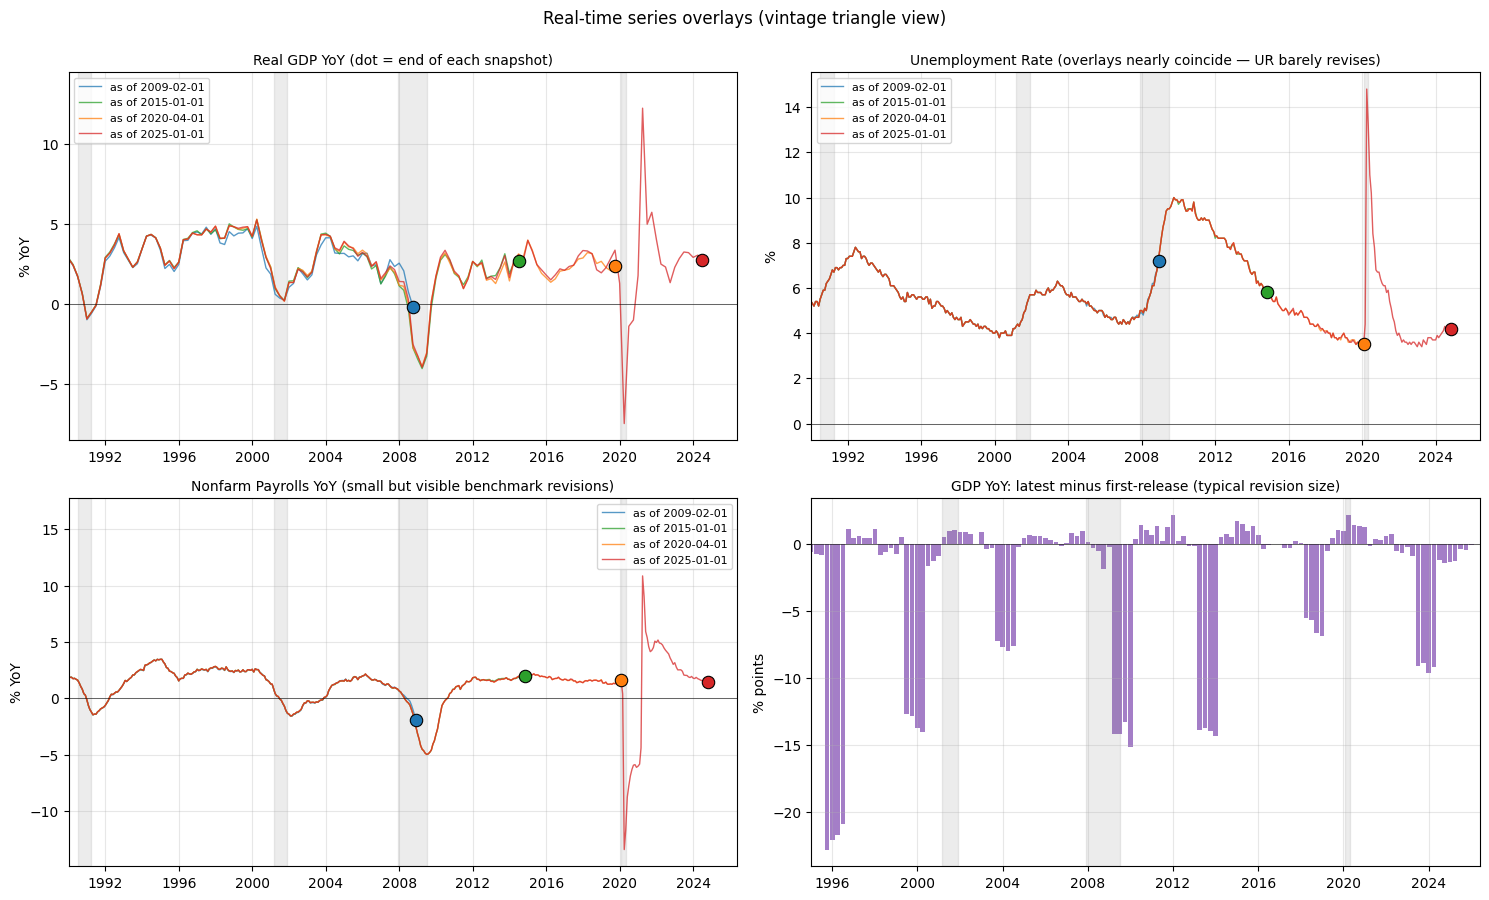

In [3]:
vintage_dates = ['2009-02-01', '2015-01-01', '2020-04-01', '2025-01-01']
colors        = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

def overlay_panel(ax, code, transform_fn, ylabel, title):
    end_pts = []
    for vd, c in zip(vintage_dates, colors):
        snap = pd.to_numeric(vintage_store.snapshot_as_of(CUBES[code], vd),
                             errors='coerce').dropna()
        y = transform_fn(snap).dropna()
        ax.plot(y.index, y.values, lw=1.0, color=c, alpha=0.75,
                label=f'as of {vd}')
        if len(y):
            end_pts.append((y.index[-1], y.iloc[-1], c))
    for x, val, c in end_pts:
        ax.scatter([x], [val], color=c, s=80, zorder=5,
                   edgecolor='black', linewidth=0.8)
    for s_, e_ in BANDS:
        ax.axvspan(s_, e_, color='grey', alpha=0.15)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xlim(pd.Timestamp('1990-01-01'), pd.Timestamp('2026-06-01'))
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    ax.axhline(0, color='black', lw=0.4)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

overlay_panel(axes[0,0], 'GDPC1',
              lambda s: 100*(s - s.shift(4))/s.shift(4),
              '% YoY', 'Real GDP YoY (dot = end of each snapshot)')
overlay_panel(axes[0,1], 'UNRATE',
              lambda s: s,
              '%', 'Unemployment Rate (overlays nearly coincide — UR barely revises)')
overlay_panel(axes[1,0], 'PAYEMS',
              lambda s: 100*(s - s.shift(12))/s.shift(12),
              '% YoY', 'Nonfarm Payrolls YoY (small but visible benchmark revisions)')

# Bottom-right: revision-size bar plot for GDP YoY
ax = axes[1,1]
latest = pd.to_numeric(vintage_store.snapshot_as_of(CUBES['GDPC1'], '2026-05-01'),
                       errors='coerce').dropna()
fr     = pd.to_numeric(vintage_store.first_release_series(CUBES['GDPC1']),
                       errors='coerce').dropna()
latest_yoy = 100*(latest - latest.shift(4))/latest.shift(4)
fr_yoy     = 100*(fr     - fr.shift(4))    /fr.shift(4)
diff = (latest_yoy - fr_yoy).loc['1995-01-01':]
ax.bar(diff.index, diff.values, width=80, color='#9467bd', alpha=0.85)
for s_, e_ in BANDS:
    ax.axvspan(s_, e_, color='grey', alpha=0.15)
ax.axhline(0, color='black', lw=0.4)
ax.set_title('GDP YoY: latest minus first-release (typical revision size)', fontsize=10)
ax.set_ylabel('% points')
ax.grid(alpha=0.3)
ax.set_xlim(pd.Timestamp('1995-01-01'), pd.Timestamp('2026-06-01'))

fig.suptitle('Real-time series overlays (vintage triangle view)', y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

## Takeaways for the paper

- **GDP and payrolls revisions are dominated by base-year rebasings**, not by sequentially-released estimates of the same number. This is the strongest argument for the vintage cube: first-release-level approaches confound real revisions with deflator changes.
- **Unemployment and CPI revise very little**, so for those series the gain from vintage discipline is small (but the harness still uses it for consistency).
- **Michigan Sentiment doesn't revise historical values at all** — it only publishes preliminary and final for the *current* month. Vintage discipline for UMCSENT mostly matters at the recent edge, not historically.
- The asymmetry between hard (revising) and soft (mostly not) is itself relevant to the soft-vs-hard story: even setting forecasting accuracy aside, soft data is more *stable* in real time, which is one practical reason a forecaster might lean on it.